# CIFAR-10 Project (Part 1) - Baseline CNN Model
The goal of the notebook is to build a simple convolutional neural network (CNN) for CIFAR-10 classification  
This model will be used as a baseline  

Later notebooks:  
`02_cifar10_improvements` - model improvement  
`03_error_analysis` - model error analysis  

## Importing and Setting Up the Environment

The following steps were taken first:

- Importing all necessary libraries
- Creating the `results/` folder
- Checking the TensorFlow version
- Checking the availability of a graphics processing unit (GPU)

These steps ensure that the environment is ready for training

In [3]:
import sys
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import cifar10
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix
from pathlib import Path

RESULTS = Path("../results")
RESULTS.mkdir(parents = True, exist_ok = True)
RESULTS

print(sys.executable)
print(tf.__version__)
print(tf.config.list_physical_devices("GPU"))

C:\Users\lb_20\Desktop\Projects\cnn_generalization_project\venv\Scripts\python.exe
2.20.0
[]


## CIFAR-10 dataset

Downloading the CIFAR-10 dataset from Keras  

The dataset contains:  
- 50 000 training images
- 10 000 test images
- 10 classes (airplane, cat, truck, etc.)

Each image is 32×32 pixels with 3 color channels (RGB)

In [5]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("train:", X_train.shape, y_train.shape)
print("test:", X_test.shape, y_test.shape)

train: (50000, 32, 32, 3) (50000, 1)
test: (10000, 32, 32, 3) (10000, 1)


C:\Users\lb_20\Desktop\Projects\cnn_generalization_project\venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


## Visualization of Sample Images

I display 16 random training images  

This helps to:  
- Understand the dataset
- See the resolution of the images
- Confirm the correctness of the labels

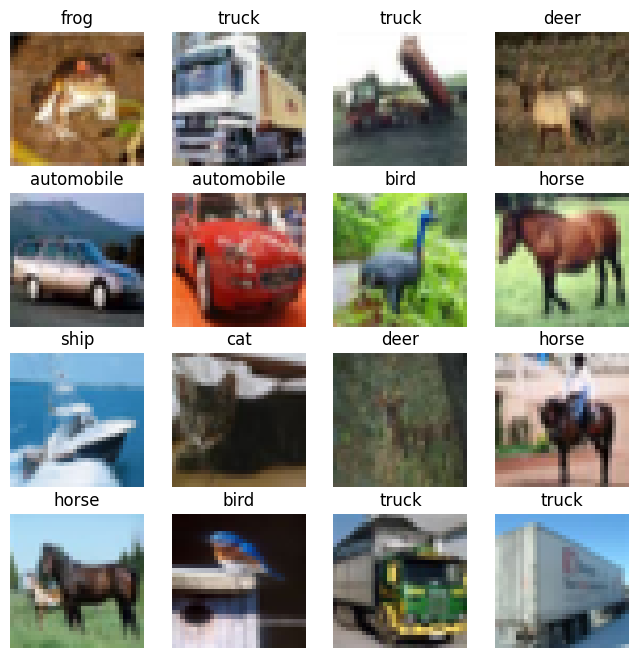

In [7]:
class_names = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

plt.figure(figsize = (8,8))

for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.show()

## Normalization of Pixel Values

Pixel values were scaled from:  
0-255 to 0-1

This helps:  
- Faster training
- More stable gradients
- Better model convergence

In [9]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print(X_train.min(), X_train.max())

0.0 1.0


## Train / Validation Split


The training data was split into:  
- Training set (90%)
- Validation set (10%)

The validation data is used for:  
- Overfitting monitoring
- Model tuning
- Comparing performance during training

In [11]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size = 0.1, random_state = 0, stratify = y_train)

print("train:", X_train.shape)
print("validation:", X_val.shape)
print("test:", X_test.shape)

train: (45000, 32, 32, 3)
validation: (5000, 32, 32, 3)
test: (10000, 32, 32, 3)


## Build Baseline CNN Model

A simple CNN was created using:  
- Conv2D layers (feature extraction)
- MaxPooling layers (downsampling)
- Dense layers (classification)
- Softmax output (10 classes)

This is a simple baseline model without regularization or advanced techniques

In [13]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation = "relu", input_shape = (32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation = "relu"),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3), activation = "relu"),
    
    layers.Flatten(),
    layers.Dense(128, activation = "relu"),
    layers.Dense(10, activation = "softmax")])

model.summary()

model.save(RESULTS / "baseline_model.keras")

C:\Users\lb_20\Desktop\Projects\cnn_generalization_project\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 4, 4, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

## Compile and Train the Model

The model was compiled using:  
- Optimizer: Adam
- Loss: Sparse Categorical Crossentropy
- Metric: Accuracy
 
The model was then trained for 12 epochs  
Training history is saved for later analysis

In [15]:
model.compile(
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"])

history = model.fit(X_train, y_train,
                    epochs = 12,
                    batch_size = 64,
                    validation_data = (X_val, y_val))

pd.DataFrame(history.history).to_csv(RESULTS / "baseline_history.csv", index = False)

Epoch 1/12
100/704 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.1694 - loss: 2.1876

KeyboardInterrupt: 

## Training Curves

The plot shows:  
- Training vs Validation Loss
- Training vs Validation Accuracy

This helps to detect:  
- Overfitting
- Underfitting
- Training stability

In [ ]:
hist = pd.DataFrame(history.history)

plt.figure()
plt.plot(hist["loss"], label = "train loss")
plt.plot(hist["val_loss"], label = "val loss")
plt.legend()
plt.title("Loss")
plt.show()

plt.figure()
plt.plot(hist["accuracy"], label = "train acc")
plt.plot(hist["val_accuracy"], label = "val acc")
plt.legend()
plt.title("Accuracy")
plt.show()

## Evaluate on Test Set

The model was evaluated on the test dataset   

Was recorded:   
- Best validation accuracy
- Final test accuracy

This shows how well the model generalizes to unseen data

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose = 0)
print("final val_accuracy =", max(history.history["val_accuracy"]))
print("test accuracy =", test_acc)

with open(RESULTS / "baseline_metrics.txt", "w") as f:
    f.write(f"test_accuracy = {test_acc}\n")
    f.write(f"best_val_accuracy = {max(history.history['val_accuracy'])}\n")

## Confusion Matrix

The confusion matrix was computed on test predictions

This helps to:
- See which classes are confused
- Understand class-level performance
- Identify weak classes

The confusion matrix image is saved to the results folder

In [ ]:
y_pred = model.predict(X_test)
y_pred_classes = y_pred.argmax(axis = 1)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize = (8,6))
sns.heatmap(cm, annot = True, fmt = "d")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.savefig(RESULTS / "baseline_confusion_matrix.png")
plt.show()

## Baseline Model Summary

Final Test Accuracy: ~0.71-0.72  

Observations:  
- The model learns basic features
- Some classes are easier (truck, frog)
- Some classes are harder (cat, deer)  
- Overfitting starts after several epochs

Next Step:  
Improve the model architecture in `02_cifar10_improvements`